In [ ]:
# Set seeds for reproducibility of any randomized operations
import os, random
import numpy as np
import tensorflow as tf
os.environ['PYTHONHASHSEED']='42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
print('Seeds set (42).')


### Note on Data Leakage
This notebook does not train or tune on the test set; pre-trained weights are loaded and evaluated once on the test set.

(78585, 1047) (78585, 1)
241
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_24 (Conv1D)          (None, 1047, 32)          128       
                                                                 
 batch_normalization_24 (Bat  (None, 1047, 32)         128       
 chNormalization)                                                
                                                                 
 dropout_24 (Dropout)        (None, 1047, 32)          0         
                                                                 
 conv1d_25 (Conv1D)          (None, 1047, 128)         12416     
                                                                 
 batch_normalization_25 (Bat  (None, 1047, 128)        512       
 chNormalization)                                                
                                                                 
 dropout_25 (Dropout)    

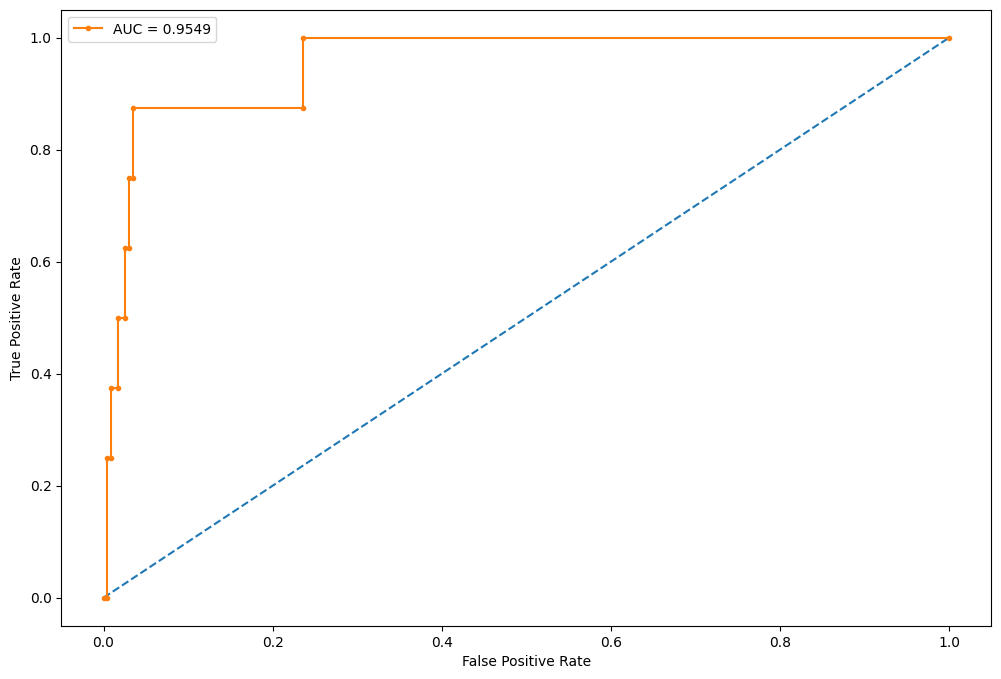

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score 
import warnings
import pickle 
import copy
from matplotlib import pyplot
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)
import tensorflow as tf
import tensorflow.keras.layers as tfl

with open("features_data/diversity/train_dataset_1.pkl", 'rb') as file:
    positive_set = pickle.load(file)

with open("features_data/diversity/train_dataset_0.pkl", 'rb') as file:
    negative_set_entire = pickle.load(file)
column_names = ['pdb_name','residue','features','label']
# 确保 positive_set 和 negative_set_entire 是 DataFrame
if isinstance(positive_set, dict):
    positive_set = pd.DataFrame.from_dict(positive_set)
if isinstance(negative_set_entire, dict):
    negative_set_entire = pd.DataFrame.from_dict(negative_set_entire)

Negative_Samples = negative_set_entire.sample(n=round(len(positive_set)*14), random_state=42)

# combine positive and negative sets to make the final dataset
Train_set = pd.concat([positive_set, Negative_Samples], ignore_index=True, axis=0)

# collect the features and labels of train set
np.set_printoptions(suppress=True)
X_val = [0]*len(Train_set)
for i in range(len(Train_set)):
    feat = Train_set['features'][i]
    # feat = np.concatenate((feat[:1024],feat[1044:]))
    X_val[i] = feat
X_train_orig = np.asarray(X_val)
y_val = Train_set['label'].to_numpy(dtype=float)
Y_train_orig = y_val.reshape(y_val.size,1)

# Generate a random order of elements with np.random.permutation and simply index into the arrays Feature and label 
idx = np.random.permutation(len(X_train_orig))
X_train,Y_train = X_train_orig[idx], Y_train_orig[idx]
scaler = StandardScaler()
scaler.fit(X_train) # fit on training set only
X_train = scaler.transform(X_train) # apply transform to the training set
print(X_train.shape, Y_train.shape)




# load test data features_data/D157_dataset1.pkl
with open("allo_data/2V4Y_A_dataset.pkl", 'rb') as file:
    test_set_entire = pickle.load(file)
column_names = ['pdb_name','residue','features','label']
# 确保 positive_set 和 negative_set_entire 是 DataFrame
if isinstance(test_set_entire, dict):
    test_set = pd.DataFrame.from_dict(test_set_entire)
res_len=len(test_set['residue'])
print(res_len)
# collect the features and labels for independent set
X_independent = [0]*len(test_set)
for i in range(len(test_set)):
    feat1 = test_set['features'][i]
    X_independent[i] = feat1
X_test = np.asarray(X_independent)

y_independent = test_set['label'].to_numpy(dtype=float)
Y_test = y_independent.reshape(y_independent.size,1)

X_test = scaler.transform(X_test) # apply standardization (transform) to the test set

test_set
def CNN_Model():
    
    model = tf.keras.Sequential()
    model.add(tfl.Conv1D(32, 3, padding='same', activation='relu', input_shape=(feat_shape,1)))
    model.add(tfl.BatchNormalization())
    model.add(tfl.Dropout(0.2)) 

    model.add(tfl.Conv1D(128, 3, padding='same',activation='relu'))
    model.add(tfl.BatchNormalization())
    model.add(tfl.Dropout(0.3)) 

    model.add(tfl.Conv1D(32, 5, padding='same',activation='relu'))
    model.add(tfl.BatchNormalization()) 
    model.add(tfl.Dropout(0.2)) 

    model.add(tfl.Conv1D(32, 3, padding='same',activation='relu'))
    model.add(tfl.BatchNormalization()) 
    model.add(tfl.Dropout(0.3)) 

    model.add(tfl.Flatten())
    model.add(tfl.Dense(128, activation='relu'))


    model.add(tfl.Dense(32, activation='relu'))
    model.add(tfl.Dense(1, activation='sigmoid'))
    
    
    return model

feat_shape = X_test[0].size # number of features

cnn_model = CNN_Model()

learning_rate = 0.00001
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cnn_model.compile(optimizer=optimizer,
                   loss='binary_crossentropy',
                   metrics=['AUC'])

cnn_model.summary()

# load the trained weights
# cnn_model.load_weights('model/embedding-pssm-bio/dataset_best_model_weights_rerun_8.h5')
cnn_model.load_weights('myModel/trial1.h5')
eval_result = cnn_model.evaluate(X_test, Y_test)

print(f"test loss: {round(eval_result[0],4)}, test auc: {round(eval_result[1],4)}")
Inde_test_prob = cnn_model.predict(X_test)


for i, prob in enumerate(Inde_test_prob):
    # print(f"Sample {i}: Probability of being positive class = {prob[0]}")
    if(prob[0]>0.5):
        # print(X_test[i])
        print(f"Sample {i}: Probability of being positive class = {prob[0]}")
        # 输出别构残基的resid
        print(f"african_sites:{test_set['residue'][i]}")

def round_based_on_thres(probs_to_round, set_thres):
    for i in range(len(probs_to_round)):
        probs_to_round[i] = 1 if probs_to_round[i] > set_thres else 0
    return probs_to_round

# Robust evaluation with proper types and class checks
set_thres = 0.5
# Flatten scores
y_scores = np.asarray(Inde_test_prob).reshape(-1).astype(float)
# Normalize labels to 0/1 from test_set and flatten
if isinstance(test_set_entire, dict):
    test_set = pd.DataFrame.from_dict(test_set_entire)
if 'label' in test_set.columns:
    y_true = test_set['label'].map(lambda x: 1 if str(x).strip() in {'1','True','true'} else 0).to_numpy(dtype=int).reshape(-1)
else:
    raise ValueError('Test set has no label column for evaluation')

# Binary predictions from threshold
y_pred = (y_scores >= set_thres).astype(int)

from sklearn.metrics import precision_score, confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
# Handle edge case when only one class present in y_true
if cm.shape == (2,2):
    tn, fp, fn, tp = cm.ravel()
else:
    # Single-class: infer counts
    if (y_true==1).any():
        tn, fp, fn, tp = 0, 0, 0, cm[0,0]
    else:
        tn, fp, fn, tp = cm[0,0], 0, 0, 0

total = cm.sum()
inde_pre = round(precision_score(y_true, y_pred, zero_division=0), 4)
inde_sen = round(tp / (tp + fn + 1e-9), 4)
inde_spe = round(tn / (tn + fp + 1e-9), 4)
acc = round((tp + tn) / (total + 1e-9), 4)

# Compute ROC/AUC only if both classes exist
try:
    from sklearn.metrics import roc_curve, roc_auc_score
    if (y_true == 1).any() and (y_true == 0).any():
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        inde_auc = round(roc_auc_score(y_true, y_scores), 4)
    else:
        fpr, tpr, thresholds, inde_auc = None, None, None, float('nan')
except Exception:
    fpr, tpr, thresholds, inde_auc = None, None, None, float('nan')

# Display metrics
print(f'Independent Sen: {inde_sen}')
print(f'Independent Spe: {inde_spe}')
print(f'Independent Pre: {inde_pre}')
print(f'Independent AUC: {inde_auc}')
print(f'ACC: {acc}')

# Plot ROC if valid
if fpr is not None:
    legend = 'AUC = ' + str(inde_auc)
    pyplot.figure(figsize=(12,8))
    pyplot.plot([0,1], [0,1], linestyle='--')
    pyplot.plot(fpr, tpr, marker='.', label=legend)
    pyplot.xlabel('False Positive Rate')
    pyplot.ylabel('True Positive Rate')
    pyplot.legend()
    pyplot.show()
else:
    print('ROC not available (single-class labels)')


## Optional: Topology Augmentation (DCI + Betweenness)
Run this cell to execute a full evaluation with DCI (2D) + betweenness (1D) appended to baseline features.
- Requires PDBs under `AlloFusion-main/Case Study` or `Case Study`.
- Dependencies: install `prody` and `networkx`.
- This cell is self-contained and does not modify the main baseline cell above.


In [ ]:
# Toggle to run augmented pipeline
USE_DCI_BETWEENNESS = True  # set True to run with 1050D features

from pathlib import Path
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import tensorflow.keras.layers as tfl
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, confusion_matrix
from matplotlib import pyplot as plt

def _augment_df_with_topology(df, pdb_cache_dir, cutoff=8.0, sigma=4.0):
    try:
        from tda_adapter.dci import compute_and_cache_dci
        from utils.graph_features import compute_betweenness_centrality
    except Exception as e:
        print(f'[Topo] Missing deps ({e}); install: pip install prody networkx')
        return df
    out = df.copy()
    extras = {}
    for name, grp in out.groupby('pdb_name', sort=False):
        nm = str(name).strip('>')
        parts = nm.split('_')
        L = len(grp)
        dci = np.zeros((L, 2), dtype=float)
        btw = np.zeros(L, dtype=float)
        if len(parts) == 2:
            pdb_id, chain_id = parts
            pdb_path = Path(pdb_cache_dir) / f'{pdb_id}.pdb'
            try:
                if pdb_path.exists():
                    dci_raw = compute_and_cache_dci(str(pdb_path), chain_id, cache_dir=str(pdb_cache_dir), cutoff=cutoff)
                    m = min(L, dci_raw.shape[0]) if dci_raw is not None else 0
                    if m > 0:
                        dci[:m] = dci_raw[:m]
                    btw_raw = compute_betweenness_centrality(str(pdb_path), chain_id, cutoff=cutoff, sigma=sigma, normalize=True)
                    m2 = min(L, btw_raw.shape[0]) if btw_raw is not None else 0
                    if m2 > 0:
                        btw[:m2] = btw_raw[:m2]
            except Exception as e:
                print(f'[Topo] {nm}: failed ({e}); using zeros')
        else:
            print(f'[Topo] Unrecognized pdb_name format: {name}; using zeros')
        extras[name] = (dci, btw)
    counters = {}
    new_feats = []
    for idx, row in out.iterrows():
        name = row['pdb_name']
        pos = counters.get(name, 0)
        counters[name] = pos + 1
        dci, btw = extras.get(name, (None, None))
        base = row['features']
        if dci is not None and btw is not None and pos < len(btw):
            base = np.concatenate([base, dci[pos], [btw[pos]]])
        new_feats.append(base)
    out['features'] = new_feats
    return out

def run_augmented_evaluation():
    # Paths
    DATA_DIR = Path('features_data/diversity')
    TEST_PICKLE = Path('allo_data/2V4Y_A_dataset.pkl')
    PDB_CACHE_DIR = Path('AlloFusion-main/Case Study') if Path('AlloFusion-main/Case Study').exists() else Path('Case Study')

    # Load datasets
    with open(DATA_DIR / 'train_dataset_1.pkl', 'rb') as f:
        pos = pickle.load(f)
    with open(DATA_DIR / 'train_dataset_0.pkl', 'rb') as f:
        neg_all = pickle.load(f)
    if isinstance(pos, dict): pos = pd.DataFrame.from_dict(pos)
    if isinstance(neg_all, dict): neg_all = pd.DataFrame.from_dict(neg_all)
    neg = neg_all.sample(n=round(len(pos)*14), random_state=42)
    train_df = pd.concat([pos, neg], ignore_index=True)

    with open(TEST_PICKLE, 'rb') as f:
        tst = pickle.load(f)
    if isinstance(tst, dict): tst = pd.DataFrame.from_dict(tst)

    # Augment
    train_df = _augment_df_with_topology(train_df, PDB_CACHE_DIR)
    tst = _augment_df_with_topology(tst, PDB_CACHE_DIR)

    # Arrays + scaling
    X_train = np.array([train_df['features'][i] for i in range(len(train_df))])
    y_train = train_df['label'].to_numpy(dtype=float).reshape(-1, 1)
    idx = np.random.permutation(len(X_train))
    X_train, y_train = X_train[idx], y_train[idx]
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = np.array([tst['features'][i] for i in range(len(tst))])
    y_test = tst['label'].to_numpy(dtype=float).reshape(-1, 1)
    X_test = scaler.transform(X_test)
    feat_shape = X_test.shape[1]

    # Model
    def build_model(fs):
        model = tf.keras.Sequential([
            tfl.Conv1D(32, 3, padding='same', activation='relu', input_shape=(fs,1)),
            tfl.BatchNormalization(),
            tfl.Dropout(0.2),
            tfl.Conv1D(128, 3, padding='same', activation='relu'),
            tfl.BatchNormalization(),
            tfl.Dropout(0.3),
            tfl.Conv1D(32, 5, padding='same', activation='relu'),
            tfl.BatchNormalization(),
            tfl.Dropout(0.2),
            tfl.Conv1D(32, 3, padding='same', activation='relu'),
            tfl.BatchNormalization(),
            tfl.Dropout(0.3),
            tfl.Flatten(),
            tfl.Dense(128, activation='relu'),
            tfl.Dense(32, activation='relu'),
            tfl.Dense(1, activation='sigmoid')
        ])
        return model

    model = build_model(feat_shape)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['AUC'])

    # Load 1050D weights if available; also mirror to a standard name
    weights_1050 = Path('myModel/all_1050d.h5')
    final_ckpt = Path('myModel/final_model_1050d.h5')
    if weights_1050.exists():
        model.load_weights(str(weights_1050))
        print(f'[Load] Using weights: {weights_1050}')
        try:
            import shutil
            shutil.copyfile(str(weights_1050), str(final_ckpt))
            print(f'[Save] Mirrored to: {final_ckpt}')
        except Exception as e:
            print(f'[Save] Could not mirror weights to {final_ckpt}: {e}')
    else:
        print('[WARN] 1050D weights not found at myModel/all_1050d.h5; evaluating with randomly initialized weights')

    # Evaluate
    res = model.evaluate(X_test, y_test, verbose=0)
    print(f'AUGMENTED test loss: {res[0]:.4f}, AUC: {res[1]:.4f}')
    y_prob = model.predict(X_test, verbose=0)
    thr = 0.5
    y_bin = (y_prob >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    pre = precision_score(y_test, y_bin)
    cm = confusion_matrix(y_test, y_bin)
    print(f'AUGMENTED AUC: {auc:.4f}, Precision: {pre:.4f}')
    # Plot ROC
    plt.figure(figsize=(6,4))
    plt.plot([0,1],[0,1],'k--')
    plt.plot(fpr,tpr,label=f'AUC={auc:.3f}')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('Augmented ROC'); plt.show()

if USE_DCI_BETWEENNESS:
    run_augmented_evaluation()
else:
    print('Augmented pipeline is disabled (USE_DCI_BETWEENNESS = True). Set True to run 1050D evaluation.')
